# Learned cost-to-go for discrete least-action planning (Colab)

Self-contained experiment. Tests, honestly, whether a small neural network trained to
predict cost-to-go can reduce **search effort** (node expansions) for finding minimum
**action** trajectories of a 2D particle in a non-trivial potential, inside a
**bounded-suboptimal** focal search — versus the strongest cheap baselines (admissible
A\* and a coarse-DP value function).

Key design points, all load-bearing:
- **Physical cost** = discrete Lagrangian `L_d = dt*(T_kin - V)` (midpoint rule), not an engineered cost.
- **Gauge shift**: add `c = Vmax` to the Lagrangian so every edge cost is non-negative. This adds the same constant to every fixed-endpoint, fixed-step path, so the optimal path is unchanged, but the standard multiplicative bound (`cost <= W*C*`) applies again.
- **Minimising regime** (`omega*T` small) so least = stationary.
- **Leakage-guarded**: train and test goals are disjoint; labels are the exact DP cost-to-go.
- A **null result is acceptable** and interesting: if the learned heuristic does not beat admissible A\* or coarse-DP, that is a real finding.

Runs on a free Colab CPU in a few minutes. `Runtime -> Run all`.

In [1]:
import numpy as np, torch, torch.nn as nn, time, math
import matplotlib.pyplot as plt
torch.manual_seed(0); np.random.seed(0)

# ---------------- configuration ----------------
PRESET = "small"      # "small" (fast, ~1-2 min) | "large" (bigger search, a few min)
m      = 1.0          # mass
half   = 1.2          # domain is [-half, half]^2
T      = 0.3          # total time (short -> minimising regime)
vmax   = 2            # local move window (velocity-bounded), branching (2*vmax+1)^2
omega  = np.pi        # oscillator frequency for the potentials that use it
G, N   = (21, 14) if PRESET=="small" else (29, 16)   # grid points per axis, time layers
dt     = T/(N-1)
xs     = np.linspace(-half, half, G)
start  = (3, 3)       # fixed start cell (same for all goals)
print(f"preset={PRESET}: grid {G}x{G}, N_t={N}, states={G*G*N}, moves={(2*vmax+1)**2}, omega*T={omega*T/np.pi:.2f} pi")

preset=small: grid 21x21, N_t=14, states=6174, moves=25, omega*T=0.30 pi


In [2]:
# ---------------- potentials (swap POTENTIAL to explore) ----------------
def V_harmonic(x,y):   return 0.5*omega*omega*(x*x+y*y)                 # separable, closed-form heuristic exists
def V_doublewell(x,y): return 8.0*(((x*x-0.64)**2)+((y*y-0.64)**2))     # anharmonic, no closed form
def V_coupled(x,y):    return 0.5*omega*omega*(x*x+y*y)+10.0*x*x*y*y    # non-separable

POTENTIAL = "doublewell"   # "harmonic" | "doublewell" | "coupled"
Vf = {"harmonic":V_harmonic,"doublewell":V_doublewell,"coupled":V_coupled}[POTENTIAL]

def mv_list(v): return [(a,b) for a in range(-v,v+1) for b in range(-v,v+1)]
MV = mv_list(vmax)
Vgrid = np.array([[Vf(xs[i],xs[j]) for j in range(G)] for i in range(G)])
SHIFT = float(Vgrid.max())    # gauge shift c = Vmax  ->  edge cost dt*(T_kin - V + c) >= 0
print(f"potential = {POTENTIAL},  gauge shift c = Vmax = {SHIFT:.3f}")

def ecf(i,j,i2,j2,sh=SHIFT):
    x1,y1,x2,y2 = xs[i],xs[j],xs[i2],xs[j2]
    return dt*(0.5*m*((x2-x1)**2+(y2-y1)**2)/dt**2 - Vf(0.5*(x1+x2),0.5*(y1+y2)) + sh)

def roll_get(a,di,dj):
    Gn=a.shape[0]; b=np.full((Gn,Gn),np.inf)
    id0,id1=max(0,-di),Gn-max(0,di); is0,is1=max(0,di),Gn-max(0,-di)
    jd0,jd1=max(0,-dj),Gn-max(0,dj); js0,js1=max(0,dj),Gn-max(0,-dj)
    b[id0:id1,jd0:jd1]=a[is0:is1,js0:js1]; return b

def build_ecg(xsg,mv,sh):
    Gn=len(xsg); I,J=np.meshgrid(range(Gn),range(Gn),indexing='ij'); x1=xsg[I]; y1=xsg[J]; ecg={}
    for (di,dj) in mv:
        i2=I+di; j2=J+dj; valid=(i2>=0)&(i2<Gn)&(j2>=0)&(j2<Gn)
        x2=xsg[np.clip(i2,0,Gn-1)]; y2=xsg[np.clip(j2,0,Gn-1)]
        v2=((x2-x1)**2+(y2-y1)**2)/dt**2
        ecg[(di,dj)]=np.where(valid, dt*(0.5*m*v2 - Vf(0.5*(x1+x2),0.5*(y1+y2)) + sh), np.inf)
    return ecg

def value_fn(xsg,mv,sh,g):
    "Exact backward cost-to-go value function on grid xsg (also gives C* at the start)."
    Gn=len(xsg); ecg=build_ecg(xsg,mv,sh)
    val=np.full((N,Gn,Gn),np.inf); val[N-1,g[0],g[1]]=0.0
    for k in range(N-2,-1,-1):
        best=np.full((Gn,Gn),np.inf)
        for (di,dj) in mv: best=np.minimum(best, ecg[(di,dj)]+roll_get(val[k+1],di,dj))
        val[k]=best
    return val

potential = doublewell,  gauge shift c = Vmax = 10.240


In [3]:
# ---------------- gauge-invariance check (the optimal path is unchanged) ----------------
_g=(G-4,G-4)
_vs=value_fn(xs,MV,SHIFT,_g); _vu=value_fn(xs,MV,0.0,_g)
_Cs=_vs[0,start[0],start[1]]; _Cu=_vu[0,start[0],start[1]]
assert abs((_Cs-SHIFT*(N-1)*dt)-_Cu)<1e-6, "gauge shift changed the optimum!"
print(f"gauge check OK: shifted C* - c*T = {_Cs-SHIFT*(N-1)*dt:.4f} == unshifted C* = {_Cu:.4f}")
def Cstar(g): return value_fn(xs,MV,SHIFT,g)[0,start[0],start[1]]

gauge check OK: shifted C* - c*T = 8.9193 == unshifted C* = 8.9193


## Dataset and leakage-guarded split

Goals are split into disjoint **train** and **test** sets. Training labels are the **exact**
gauge-shifted cost-to-go from backward DP on the *train* goals only. Features are a normalized
`(state, goal)` vector. The test goals are never seen in training.

In [4]:
rng=np.random.default_rng(42)
allg=[(i,j) for i in range(4,G-3) for j in range(4,G-3)]
rng.shuffle(allg)
test_goals  = allg[:6]
train_goals = allg[6:22]
assert set(train_goals).isdisjoint(set(test_goals)), "train/test leakage!"
print(f"{len(train_goals)} train goals, {len(test_goals)} test goals (disjoint)")

def features(i,j,k,g):
    return [xs[i]/half, xs[j]/half, xs[g[0]]/half, xs[g[1]]/half,
            (xs[g[0]]-xs[i])/(2*half), (xs[g[1]]-xs[j])/(2*half),
            (N-1-k)/(N-1), np.hypot(xs[g[0]]-xs[i], xs[g[1]]-xs[j])/(2*np.sqrt(2)*half)]

Xl=[]; Yl=[]
for g in train_goals:
    v=value_fn(xs,MV,SHIFT,g)
    for k in range(N-1):
        fi,fj=np.where(np.isfinite(v[k]))
        for i,j in zip(fi,fj): Xl.append(features(i,j,k,g)); Yl.append(v[k,i,j])
X=np.array(Xl,dtype=np.float32); Y=np.array(Yl,dtype=np.float32)
ymu,ysd=float(Y.mean()),float(Y.std()+1e-8)
print("dataset:",X.shape,"label range [%.2f, %.2f]"%(Y.min(),Y.max()))

16 train goals, 6 test goals (disjoint)
dataset: (67427, 8) label range [0.10, 19.32]


In [5]:
# ---------------- train the cost-to-go MLP ----------------
class MLP(nn.Module):
    def __init__(s,din=8):
        super().__init__()
        s.net=nn.Sequential(nn.Linear(din,128),nn.ReLU(),nn.Linear(128,128),nn.ReLU(),nn.Linear(128,1))
    def forward(s,x): return s.net(x).squeeze(-1)

Xt=torch.tensor(X); Yt=torch.tensor((Y-ymu)/ysd)
n=len(Xt); idx=torch.randperm(n); ntr=int(0.85*n)
tr,va=idx[:ntr],idx[ntr:]
model=MLP(); opt=torch.optim.Adam(model.parameters(),lr=1e-3); lossf=nn.MSELoss()
for ep in range(40):
    model.train()
    for b in range(0,len(tr),256):
        bi=tr[b:b+256]; opt.zero_grad()
        l=lossf(model(Xt[bi]),Yt[bi]); l.backward(); opt.step()
model.eval()
with torch.no_grad():
    pv=model(Xt[va]); yv=Yt[va]
    mae=(pv-yv).abs().mean().item()*ysd
    r2=1-((pv-yv)**2).sum().item()/(((yv-yv.mean())**2).sum().item()+1e-9)
print(f"held-out (val) MAE={mae:.4f} action units, R2={r2:.3f}   <-- if R2 is low, the guide is just noisy")

def learned_table(g):
    "Batch-predict the cost-to-go table val[k,i,j] for one goal (fast heuristic lookup)."
    feats=[]; idxs=[]
    for k in range(N):
        for i in range(G):
            for j in range(G):
                feats.append(features(i,j,k,g)); idxs.append((k,i,j))
    with torch.no_grad():
        pred=model(torch.tensor(np.array(feats,dtype=np.float32))).numpy()*ysd+ymu
    tab=np.zeros((N,G,G))
    for (k,i,j),p in zip(idxs,pred): tab[k,i,j]=p
    return tab

_LT={}                                  # cache learned tables per goal (reused across methods)
def lt(g):
    if g not in _LT: _LT[g]=learned_table(g)
    return _LT[g]

held-out (val) MAE=0.0349 action units, R2=1.000   <-- if R2 is low, the guide is just noisy


In [6]:
# ---------------- heuristics ----------------
def h_adm(i,j,k,g):                     # admissible lower bound (kinetic, gauge-shifted -> >=0)
    tr=(N-1-k)*dt
    return 0.0 if tr<=0 else 0.5*m*((xs[g[0]]-xs[i])**2+(xs[g[1]]-xs[j])**2)/tr

Gc=11; xsc=np.linspace(-half,half,Gc); MVc=mv_list(1)     # coarse-DP value-function heuristic
f2c=np.array([np.argmin(np.abs(xsc-x)) for x in xs])
def make_h_coarse(g):
    vc=value_fn(xsc,MVc,SHIFT,(int(f2c[g[0]]),int(f2c[g[1]])))
    def h(i,j,k,gg):
        x=vc[k,f2c[i],f2c[j]]; return x if np.isfinite(x) else 1e9
    return h
def make_h_learned(g):
    tab=lt(g)
    return lambda i,j,k,gg: tab[k,i,j]

In [7]:
import heapq
# ---------------- bounded-suboptimal focal search (non-negative costs) ----------------
def focal(g, h_guide, W):
    "OPEN by admissible f=g+h_adm; FOCAL={f<=W*fmin}; expand min h_guide. cost<=W*C*."
    S=(start[0],start[1],0); goal=(g[0],g[1],N-1)
    bg={S:0.0}; par={S:None}; openS={S}; exp=0; hA={}; hG={}
    def gA(st):
        if st not in hA: hA[st]=h_adm(st[0],st[1],st[2],g)
        return hA[st]
    def gG(st):
        if st not in hG: hG[st]=h_guide(st[0],st[1],st[2],g)
        return hG[st]
    while openS:
        fmin=min(bg[st]+gA(st) for st in openS); thr=W*fmin
        foc=[st for st in openS if bg[st]+gA(st)<=thr]
        cur=min(foc,key=gG); openS.discard(cur); exp+=1
        if cur==goal:
            path=[]; c=cur
            while c is not None: path.append((c[0],c[1])); c=par[c]
            return bg[cur],exp,path[::-1]
        i,j,k=cur
        if k==N-1: continue
        gc=bg[cur]
        for di,dj in MV:
            i2,j2=i+di,j+dj
            if 0<=i2<G and 0<=j2<G:
                ns=(i2,j2,k+1); ng=gc+ecf(i,j,i2,j2)
                if ng<bg.get(ns,np.inf): bg[ns]=ng; par[ns]=cur; openS.add(ns)
    return np.inf,exp,[]

# ---------------- weighted A* with the LEARNED heuristic as OPEN key (NO bound) ----------------
def weighted_astar(g, Wh):
    "f = g + Wh * h_learned. Inadmissible: fast, but NO suboptimality guarantee."
    tab=lt(g); S=(start[0],start[1],0); goal=(g[0],g[1],N-1)
    bg={S:0.0}; tie=0; oh=[(Wh*tab[0,S[0],S[1]],tie,0.0,S)]; tie+=1; closed=set(); exp=0
    while oh:
        f,_,gc,cur=heapq.heappop(oh)
        if cur in closed or gc>bg.get(cur,np.inf): continue
        closed.add(cur); exp+=1
        if cur==goal: return bg[cur],exp
        i,j,k=cur
        if k==N-1: continue
        for di,dj in MV:
            i2,j2=i+di,j+dj
            if 0<=i2<G and 0<=j2<G:
                ns=(i2,j2,k+1); ng=gc+ecf(i,j,i2,j2)
                if ng<bg.get(ns,np.inf):
                    bg[ns]=ng; heapq.heappush(oh,(ng+Wh*tab[k+1,i2,j2],tie,ng,ns)); tie+=1
    return np.inf,exp

In [8]:
# ---------------- benchmark on held-out goals + verification gates ----------------
W=1.5; rows=[]
for g in test_goals:
    C=Cstar(g)
    ca,ea,_ = focal(g,h_adm,1.0)                       # admissible A* (optimal baseline)
    cc,ec,_ = focal(g,make_h_coarse(g),W)              # coarse-DP guided (bounded)
    cl,el,_ = focal(g,make_h_learned(g),W)             # learned guided (bounded)
    cw,ew   = weighted_astar(g, 2.0)                   # weighted A* w/ learned (NO bound)
    rows.append((g,C,ea,ca,ec,cc,el,cl,ew,cw))
import numpy as _np
ea_m=_np.mean([r[2] for r in rows]); ec_m=_np.mean([r[4] for r in rows])
el_m=_np.mean([r[6] for r in rows]); ew_m=_np.mean([r[8] for r in rows])
sub_c=_np.mean([r[5]-r[1] for r in rows]); sub_l=_np.mean([r[7]-r[1] for r in rows]); sub_w=_np.mean([r[9]-r[1] for r in rows])
print("method                      mean_exp   mean_realized_subopt")
print(f"admissible A* (W=1)         {ea_m:8.1f}   0.000 (optimal)")
print(f"coarse-DP focal (W={W})      {ec_m:8.1f}   {sub_c:+.3f}")
print(f"learned focal (W={W})        {el_m:8.1f}   {sub_l:+.3f}")
print(f"weighted A* learned (Wh=2)  {ew_m:8.1f}   {sub_w:+.3f}   (no bound)")

# gates: fair comparison for the BOUNDED methods
assert all(abs(r[3]-r[1])<1e-6 for r in rows), "admissible A* not optimal"
assert all(r[7]<=W*r[1]+1e-6 for r in rows), "learned focal violated cost <= W*C*"
assert all(r[5]<=W*r[1]+1e-6 for r in rows), "coarse focal violated cost <= W*C*"
best_bounded = min([("admissible",ea_m),("coarse",ec_m),("learned",el_m)], key=lambda t:t[1])
print(f"\nbounded verdict: fewest expansions at bounded quality -> {best_bounded[0]} ({best_bounded[1]:.0f})")
print(f"weighted A* (unbounded) trades {sub_w:+.3f} suboptimality for {ew_m:.0f} expansions")

method                      mean_exp   mean_realized_subopt
admissible A* (W=1)            432.2   0.000 (optimal)
coarse-DP focal (W=1.5)         744.8   +0.165
learned focal (W=1.5)           650.8   +0.107
weighted A* learned (Wh=2)      14.0   +0.062   (no bound)

bounded verdict: fewest expansions at bounded quality -> admissible (432)
weighted A* (unbounded) trades +0.062 suboptimality for 14 expansions


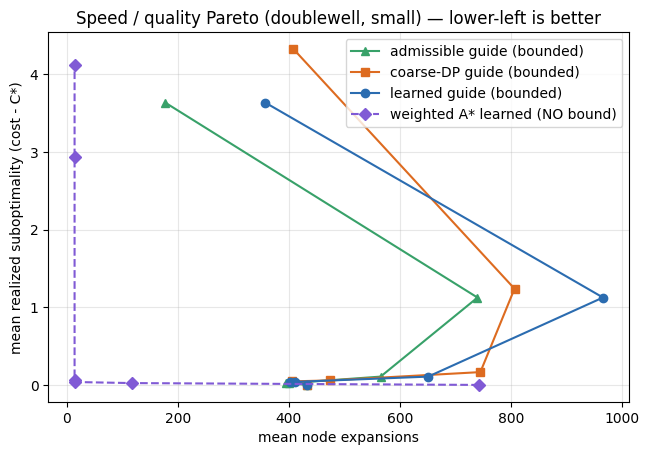

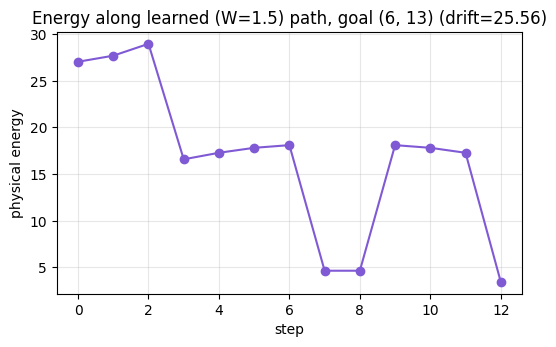

In [9]:
# ---------------- speed/quality Pareto (bounded guides + unbounded weighted A*) ----------------
Ws=[1.0,1.1,1.25,1.5,2.0,3.0]; Whs=[0.5,1.0,1.5,2.0,3.0,5.0]
def sweep_focal(mk):
    E=[];S=[]
    for w in Ws:
        e=[];s=[]
        for g in test_goals:
            C=Cstar(g); c,ex,_=focal(g,mk(g),w); e.append(ex); s.append(c-C)
        E.append(_np.mean(e)); S.append(_np.mean(s))
    return E,S
def sweep_weighted():
    E=[];S=[]
    for wh in Whs:
        e=[];s=[]
        for g in test_goals:
            C=Cstar(g); c,ex=weighted_astar(g,wh); e.append(ex); s.append(c-C)
        E.append(_np.mean(e)); S.append(_np.mean(s))
    return E,S
El,Sl=sweep_focal(make_h_learned); Ec,Sc=sweep_focal(make_h_coarse)
Ea,Sa=sweep_focal(lambda g:(lambda i,j,k,gg:h_adm(i,j,k,g))); Ew,Sw=sweep_weighted()
plt.figure(figsize=(7.5,4.8))
plt.plot(Ea,Sa,'^-',label='admissible guide (bounded)',color='#38a169')
plt.plot(Ec,Sc,'s-',label='coarse-DP guide (bounded)',color='#dd6b20')
plt.plot(El,Sl,'o-',label='learned guide (bounded)',color='#2b6cb0')
plt.plot(Ew,Sw,'D--',label='weighted A* learned (NO bound)',color='#805ad5')
plt.xlabel('mean node expansions'); plt.ylabel('mean realized suboptimality (cost - C*)')
plt.title(f'Speed / quality Pareto ({POTENTIAL}, {PRESET}) — lower-left is better'); plt.legend(); plt.grid(alpha=.3); plt.show()

g=test_goals[0]; _,_,path=focal(g,make_h_learned(g),1.5)
q=np.array([[xs[i],xs[j]] for i,j in path]); v=(q[1:]-q[:-1])/dt; qm=0.5*(q[1:]+q[:-1])
E=0.5*m*np.sum(v**2,axis=1)+np.array([Vf(a,b) for a,b in qm])
plt.figure(figsize=(6,3.4)); plt.plot(E,'o-',color='#805ad5')
plt.xlabel('step'); plt.ylabel('physical energy'); plt.title(f'Energy along learned (W=1.5) path, goal {g} (drift={E.max()-E.min():.2f})'); plt.grid(alpha=.3); plt.show()

## How to read this, honestly

- **Bounded methods** (admissible / coarse-DP / learned guide) all provably return `cost <= W*C*` — the gates enforce it. Compare them at matched (low) suboptimality: whoever is furthest **left** wins on search effort.
- **Weighted A\*** (purple, dashed) uses the learned net as the actual search heuristic. It is usually the fastest but has **no guarantee** — read it on the Pareto as a separate speed/quality point, not a like-for-like bounded method.
- If the learned curves (blue / purple) sit clearly below-left of the cheap baselines, the network is buying you something. If not, it is an honest null on this configuration.
- The **energy plot** checks physical fidelity; a W=1.5 path is bounded-suboptimal so some drift is expected — fidelity is a near-`W=1` property.

**Knobs:** `PRESET` ("small"/"large") in cell 2; `POTENTIAL` ("harmonic"/"doublewell"/"coupled") in cell 3. The learned value's advantage should grow with a harder potential and a bigger search. If cell 7's **R2 is low**, the net didn't learn the value well — add train goals or epochs before trusting a null. Past the conjugate point (`omega*T > pi`) least != stationary and this framing no longer applies.

## Final: 2x2 confirmation sweep (matched-quality)

Re-runs the whole pipeline for `{doublewell, coupled} x {small, large}`. For each config it
tunes the weighted-A\* inflation `Wh` and reports the **fastest** learned weighted-A\* that stays
**within 1% of optimal** (`TARGET_PCT`), versus admissible A\*. This is the fair, matched-quality
speedup — comparing methods at equal solution quality rather than at an arbitrary fixed `Wh`.
Columns: R2, mean C\*, admissible expansions, the chosen Wh, weighted-A\* expansions, speedup, and
the realized % suboptimality (and whether the 1% target was met). Self-contained; a few minutes on CPU.

matched-quality target: wA* within 1.0% of optimal

potential  size       R2     C*  adm_exp best_Wh  wA*_exp  speedup %subopt  met?
doublewell small   0.999   6.88    432.2    2.00     20.8    20.7x    0.67   yes
coupled    small   0.999  13.53   1139.5    1.00    178.3     6.4x    0.27   yes
doublewell large   0.999   8.76    841.0    1.50     51.5    16.3x    0.78   yes
coupled    large   0.999  15.18   2034.2    1.00    393.2     5.2x    0.24   yes


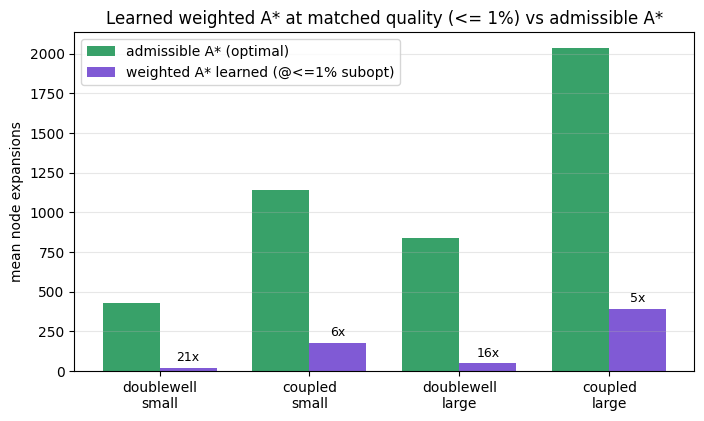

In [10]:
import heapq
TARGET_PCT = 1.0   # matched-quality target: report the fastest wA* within this % of optimal

def run_config(pot_name, Gg, Nn, epochs=25, seed=0):
    torch.manual_seed(seed); np.random.seed(seed)
    Vf_={"harmonic":V_harmonic,"doublewell":V_doublewell,"coupled":V_coupled}[pot_name]
    xs_=np.linspace(-half,half,Gg); dt_=T/(Nn-1); MV_=mv_list(vmax)
    SHIFT_=float(np.max([[Vf_(xs_[i],xs_[j]) for j in range(Gg)] for i in range(Gg)]))
    def roll_(a,di,dj):
        b=np.full((Gg,Gg),np.inf)
        id0,id1=max(0,-di),Gg-max(0,di); is0,is1=max(0,di),Gg-max(0,-di)
        jd0,jd1=max(0,-dj),Gg-max(0,dj); js0,js1=max(0,dj),Gg-max(0,-dj)
        b[id0:id1,jd0:jd1]=a[is0:is1,js0:js1]; return b
    I,J=np.meshgrid(range(Gg),range(Gg),indexing='ij'); x1=xs_[I]; y1=xs_[J]; ECG={}
    for (di,dj) in MV_:
        i2=I+di; j2=J+dj; valid=(i2>=0)&(i2<Gg)&(j2>=0)&(j2<Gg)
        x2=xs_[np.clip(i2,0,Gg-1)]; y2=xs_[np.clip(j2,0,Gg-1)]
        v2=((x2-x1)**2+(y2-y1)**2)/dt_**2
        ECG[(di,dj)]=np.where(valid, dt_*(0.5*m*v2 - Vf_(0.5*(x1+x2),0.5*(y1+y2)) + SHIFT_), np.inf)
    def value_(g):
        val=np.full((Nn,Gg,Gg),np.inf); val[Nn-1,g[0],g[1]]=0.0
        for k in range(Nn-2,-1,-1):
            best=np.full((Gg,Gg),np.inf)
            for (di,dj) in MV_: best=np.minimum(best, ECG[(di,dj)]+roll_(val[k+1],di,dj))
            val[k]=best
        return val
    def ecf_(i,j,i2,j2):
        a,b,c,d=xs_[i],xs_[j],xs_[i2],xs_[j2]
        return dt_*(0.5*m*((c-a)**2+(d-b)**2)/dt_**2 - Vf_(0.5*(a+c),0.5*(b+d)) + SHIFT_)
    def feats_(i,j,k,g):
        return [xs_[i]/half,xs_[j]/half,xs_[g[0]]/half,xs_[g[1]]/half,
                (xs_[g[0]]-xs_[i])/(2*half),(xs_[g[1]]-xs_[j])/(2*half),
                (Nn-1-k)/(Nn-1), np.hypot(xs_[g[0]]-xs_[i],xs_[g[1]]-xs_[j])/(2*np.sqrt(2)*half)]
    rng=np.random.default_rng(42)
    allg=[(i,j) for i in range(4,Gg-3) for j in range(4,Gg-3)]; rng.shuffle(allg)
    test_=allg[:6]; train_=allg[6:22]
    Xl=[];Yl=[]
    for g in train_:
        v=value_(g)
        for k in range(Nn-1):
            fi,fj=np.where(np.isfinite(v[k]))
            for i,j in zip(fi,fj): Xl.append(feats_(i,j,k,g)); Yl.append(v[k,i,j])
    X=np.array(Xl,dtype=np.float32); Y=np.array(Yl,dtype=np.float32)
    if len(X)>40000:
        sel=rng.choice(len(X),40000,replace=False); X=X[sel]; Y=Y[sel]
    mu,sd=float(Y.mean()),float(Y.std()+1e-8)
    net=MLP(); opt=torch.optim.Adam(net.parameters(),lr=1e-3); lf=nn.MSELoss()
    Xt=torch.tensor(X); Yt=torch.tensor((Y-mu)/sd); nidx=torch.randperm(len(Xt)); ntr=int(0.85*len(Xt))
    trn,val=nidx[:ntr],nidx[ntr:]
    for ep in range(epochs):
        net.train()
        for b in range(0,len(trn),256):
            bi=trn[b:b+256]; opt.zero_grad(); l=lf(net(Xt[bi]),Yt[bi]); l.backward(); opt.step()
    net.eval()
    with torch.no_grad():
        pv=net(Xt[val]); yv=Yt[val]; r2=1-((pv-yv)**2).sum().item()/(((yv-yv.mean())**2).sum().item()+1e-9)
    def table_(g):
        F=[feats_(i,j,k,g) for k in range(Nn) for i in range(Gg) for j in range(Gg)]
        with torch.no_grad(): p=net(torch.tensor(np.array(F,dtype=np.float32))).numpy()*sd+mu
        return p.reshape(Nn,Gg,Gg)
    def astar_adm(g):
        S=(start[0],start[1],0); goal=(g[0],g[1],Nn-1)
        def h(i,j,k):
            tr=(Nn-1-k)*dt_; return 0.0 if tr<=0 else 0.5*m*((xs_[g[0]]-xs_[i])**2+(xs_[g[1]]-xs_[j])**2)/tr
        bg={S:0.0}; tie=0; oh=[(h(*S),tie,0.0,S)]; tie+=1; closed=set(); exp=0
        while oh:
            f,_,gc,cur=heapq.heappop(oh)
            if cur in closed or gc>bg.get(cur,np.inf): continue
            closed.add(cur); exp+=1
            if cur==goal: return bg[cur],exp
            i,j,k=cur
            if k==Nn-1: continue
            for di,dj in MV_:
                i2,j2=i+di,j+dj
                if 0<=i2<Gg and 0<=j2<Gg:
                    ns=(i2,j2,k+1); ng=gc+ecf_(i,j,i2,j2)
                    if ng<bg.get(ns,np.inf): bg[ns]=ng; closed.discard(ns); heapq.heappush(oh,(ng+h(i2,j2,k+1),tie,ng,ns)); tie+=1
        return np.inf,exp
    def wA(g,tab,Wh):
        S=(start[0],start[1],0); goal=(g[0],g[1],Nn-1)
        bg={S:0.0}; tie=0; oh=[(Wh*tab[0,S[0],S[1]],tie,0.0,S)]; tie+=1; closed=set(); exp=0
        while oh:
            f,_,gc,cur=heapq.heappop(oh)
            if cur in closed or gc>bg.get(cur,np.inf): continue
            closed.add(cur); exp+=1
            if cur==goal: return bg[cur],exp
            i,j,k=cur
            if k==Nn-1: continue
            for di,dj in MV_:
                i2,j2=i+di,j+dj
                if 0<=i2<Gg and 0<=j2<Gg:
                    ns=(i2,j2,k+1); ng=gc+ecf_(i,j,i2,j2)
                    if ng<bg.get(ns,np.inf): bg[ns]=ng; heapq.heappush(oh,(ng+Wh*tab[k+1,i2,j2],tie,ng,ns)); tie+=1
        return np.inf,exp
    Whs=[1.0,1.25,1.5,2.0,3.0,5.0]
    ae=[]; Cs=[]; per={w:([],[]) for w in Whs}
    for g in test_:
        C=value_(g)[0,start[0],start[1]]; Cs.append(C); _,ea=astar_adm(g); ae.append(ea)
        tab=table_(g)
        for w in Whs:
            cw,ew=wA(g,tab,w); per[w][0].append(ew); per[w][1].append((cw-C)/abs(C)*100.0)
    adm=np.mean(ae)
    curve=[(w,np.mean(per[w][0]),np.mean(per[w][1])) for w in Whs]   # (Wh, exp, %subopt)
    feas=[c for c in curve if c[2]<=TARGET_PCT]
    pick=min(feas,key=lambda c:c[1]) if feas else min(curve,key=lambda c:c[2])
    return dict(R2=r2, adm=adm, Cstar=np.mean(Cs), curve=curve, met=bool(feas),
                Wh=pick[0], exp=pick[1], pct=pick[2], speedup=adm/max(pick[1],1e-9))

configs=[("doublewell",21,14),("coupled",21,14),("doublewell",29,16),("coupled",29,16)]
print(f"matched-quality target: wA* within {TARGET_PCT:.1f}% of optimal\n")
print(f"{'potential':11s}{'size':7s}{'R2':>6s}{'C*':>7s}{'adm_exp':>9s}{'best_Wh':>8s}{'wA*_exp':>9s}{'speedup':>9s}{'%subopt':>8s}{'  met?'}")
res=[]
for pot,Gg,Nn in configs:
    r=run_config(pot,Gg,Nn); res.append((pot,Gg,r)); sz="small" if Gg==21 else "large"
    print(f"{pot:11s}{sz:7s}{r['R2']:6.3f}{r['Cstar']:7.2f}{r['adm']:9.1f}{r['Wh']:8.2f}{r['exp']:9.1f}{r['speedup']:8.1f}x{r['pct']:8.2f}{'   yes' if r['met'] else '   NO'}")

import matplotlib.pyplot as plt
labels=[f"{p}\n{'small' if g==21 else 'large'}" for p,g,_ in res]
x=np.arange(len(res)); w=0.38
plt.figure(figsize=(8,4.4))
plt.bar(x-w/2,[r['adm'] for _,_,r in res],w,label='admissible A* (optimal)',color='#38a169')
plt.bar(x+w/2,[r['exp'] for _,_,r in res],w,label=f'weighted A* learned (@<={TARGET_PCT:.0f}% subopt)',color='#805ad5')
mx=max(r['adm'] for _,_,r in res)
for i,(_,_,r) in enumerate(res): plt.text(i+w/2,r['exp']+mx*0.02,f"{r['speedup']:.0f}x",ha='center',fontsize=9)
plt.xticks(x,labels); plt.ylabel('mean node expansions'); plt.title(f'Learned weighted A* at matched quality (<= {TARGET_PCT:.0f}%) vs admissible A*'); plt.legend(); plt.grid(alpha=.3,axis='y'); plt.show()